In [517]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(color_codes = True)

In [518]:
df = pd.read_csv('Food_Delivery_Times.csv')
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [519]:
#Adding Delivery_status column for classification task
df['Delivery_status'] = df['Delivery_Time_min'].apply(lambda x:'On-time' if x<=30 else 'Late')
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Delivery_status
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Late
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,Late
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Late
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Late
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,Late


In [520]:
#Removing Order_ID to reduce noise 
data_clean = df.drop(['Order_ID'],axis = 1)
data_clean

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Delivery_status
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Late
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84,Late
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Late
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Late
4,19.03,Clear,Low,Morning,Bike,16,5.0,68,Late
...,...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54,Late
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71,Late
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81,Late
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55,Late


In [521]:
#Checking for null values
data_clean.isnull().sum()

Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
Delivery_status            0
dtype: int64

In [522]:
df_copy = data_clean.copy(deep=True)

# Categorical -> mode
for col in ['Weather','Traffic_Level','Time_of_Day']:
    df_copy[col] = df_copy[col].fillna(df_copy[col].mode()[0])

# Numerical -> median
df_copy['Courier_Experience_yrs'] = df_copy['Courier_Experience_yrs'].fillna(
    df_copy['Courier_Experience_yrs'].median()
)

df_copy.isnull().sum()

Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
Delivery_status           0
dtype: int64

<Axes: xlabel='Distance_km', ylabel='Count'>

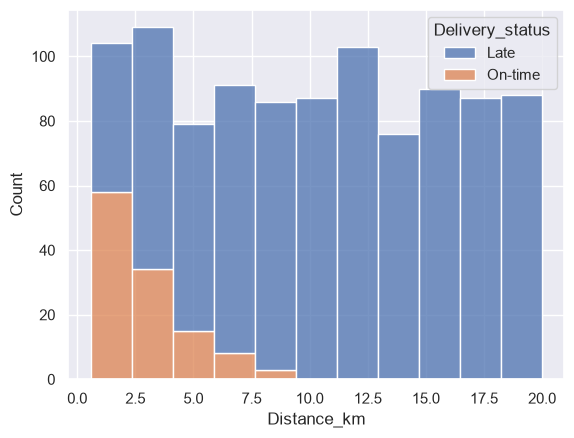

In [523]:
#EDA
sns.histplot(x = 'Distance_km',hue = 'Delivery_status', data = df_copy, multiple = 'stack')

<Axes: xlabel='Delivery_Time_min', ylabel='Count'>

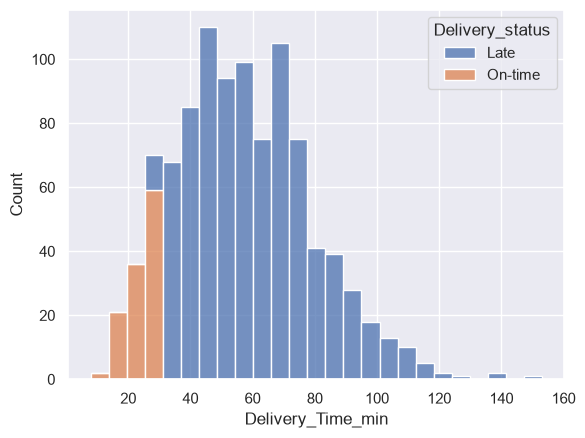

In [524]:
sns.histplot(x='Delivery_Time_min', hue='Delivery_status', data=df_copy, multiple='stack')

<Axes: xlabel='Weather', ylabel='count'>

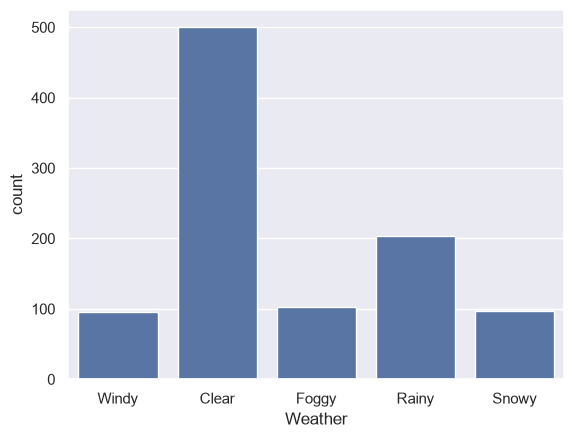

In [525]:
sns.countplot(x = 'Weather', data = df_copy)

<Axes: xlabel='Traffic_Level', ylabel='count'>

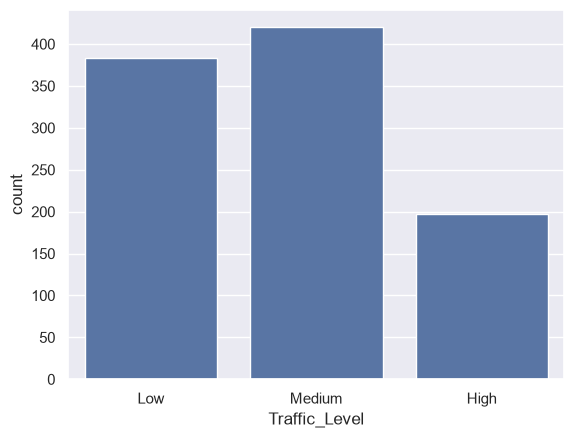

In [526]:
sns.countplot(x='Traffic_Level',data=df_copy)

<Axes: xlabel='Vehicle_Type', ylabel='count'>

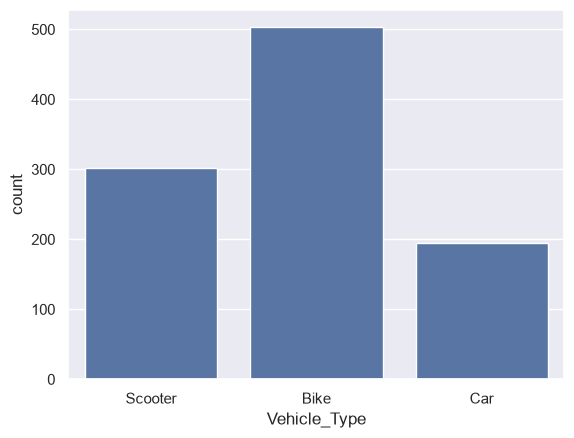

In [527]:
sns.countplot(x='Vehicle_Type',data=df_copy)

<Axes: xlabel='Distance_km'>

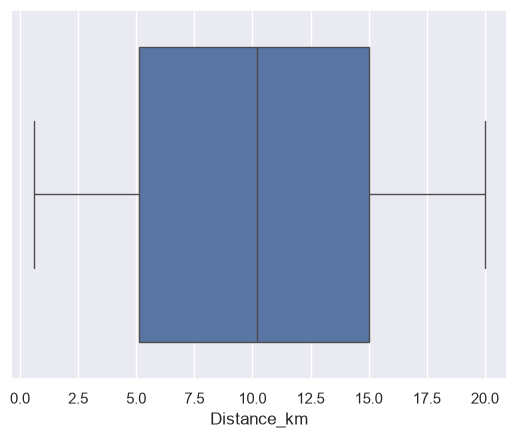

In [528]:
#Boxplot
sns.boxplot(x=df_copy['Distance_km'])

<Axes: xlabel='Preparation_Time_min'>

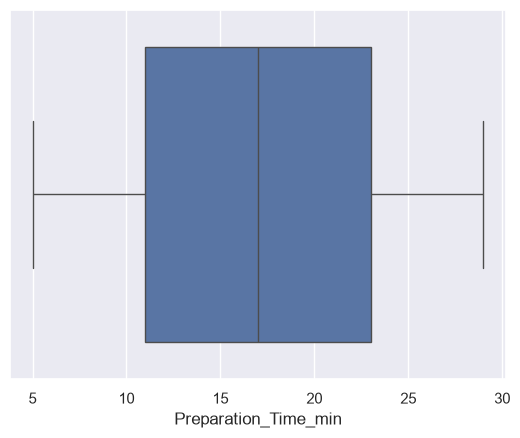

In [529]:
sns.boxplot(x = df_copy['Preparation_Time_min'])

<Axes: xlabel='Courier_Experience_yrs'>

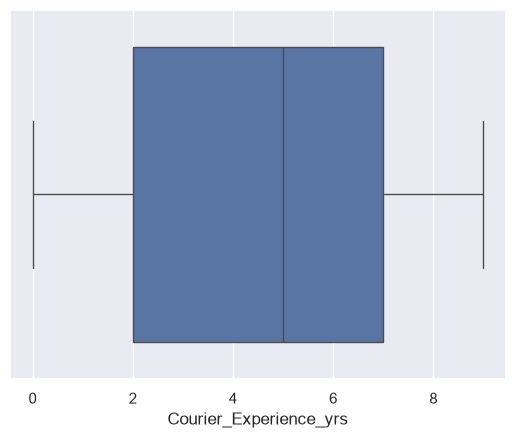

In [530]:
sns.boxplot(x = df_copy['Courier_Experience_yrs'])

<Axes: xlabel='Delivery_Time_min'>

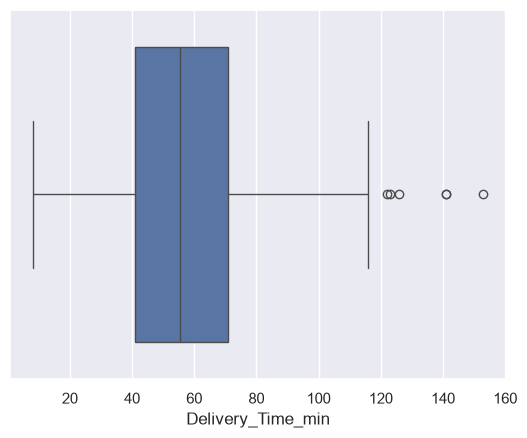

In [531]:
sns.boxplot(x = df_copy['Delivery_Time_min'])

<Axes: xlabel='Weather', ylabel='Delivery_Time_min'>

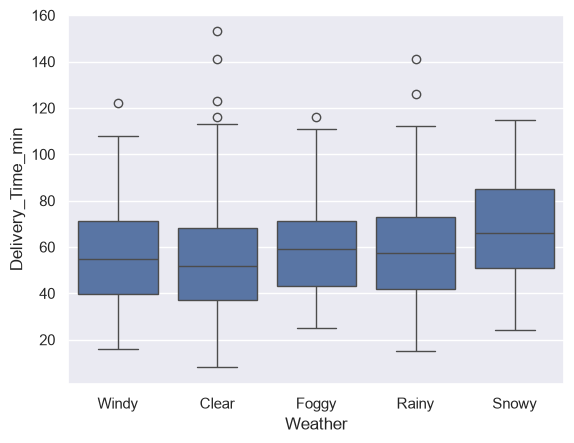

In [532]:
#Boxplot to find relationship and outliers
sns.boxplot(x='Weather', y='Delivery_Time_min', data=df_copy)

<Axes: xlabel='Traffic_Level', ylabel='Delivery_Time_min'>

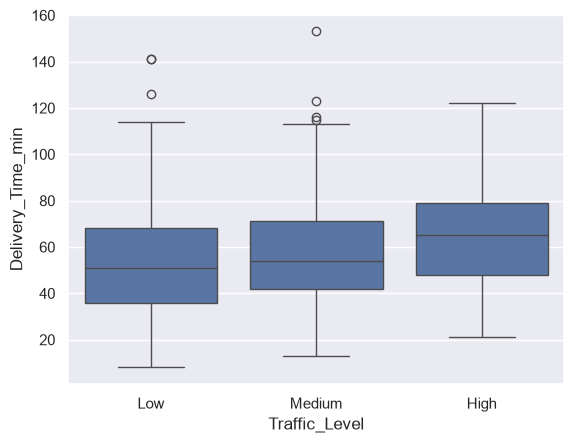

In [533]:
sns.boxplot(x='Traffic_Level', y='Delivery_Time_min', data=df_copy)

Delivery_status
Late       882
On-time    118
Name: count, dtype: int64


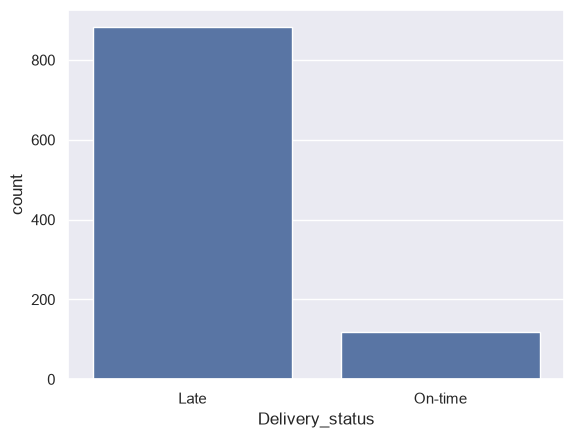

In [534]:
#Checking for imbalance
sns.countplot(x='Delivery_status' , data = df_copy)
print(df_copy.Delivery_status.value_counts())

In [535]:
#Oversampling
from sklearn.utils import resample

df_majority = df_copy[(df_copy['Delivery_status']=='Late')]
df_minority = df_copy[(df_copy['Delivery_status']=='On-time')]

df_oversampled = resample(df_minority, 
                          n_samples = 882,
                          random_state = 0)

df2 = pd.concat([df_oversampled,df_majority])

Delivery_status
On-time    882
Late       882
Name: count, dtype: int64

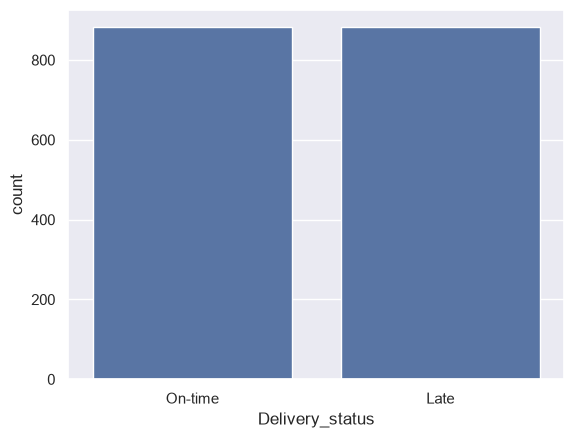

In [536]:
sns.countplot(x = 'Delivery_status', data = df2)
df2.Delivery_status.value_counts()

In [537]:
#Encoding i.e Converting Text to numbers
df2['Weather'].unique()

array(['Rainy', 'Windy', 'Clear', 'Foggy', 'Snowy'], dtype=object)

In [538]:
df2['Traffic_Level'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [539]:
df2['Time_of_Day'].unique()

array(['Evening', 'Afternoon', 'Morning', 'Night'], dtype=object)

In [540]:
df2['Vehicle_Type'].unique()

array(['Scooter', 'Car', 'Bike'], dtype=object)

In [541]:
#One-hot encoding
cat_cols = ['Weather','Traffic_Level','Time_of_Day','Vehicle_Type']
df_encoded = pd.get_dummies(df2, columns=cat_cols, drop_first=True)

df_encoded.head()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Delivery_status,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
330,3.12,14,5.0,28,On-time,False,True,False,False,True,False,True,False,False,False,True
348,2.83,14,6.0,28,On-time,False,False,False,True,False,True,False,False,False,False,True
994,4.37,6,7.0,25,On-time,False,False,False,False,False,True,True,False,False,False,True
516,2.33,6,1.0,17,On-time,False,False,False,False,True,False,False,True,False,True,False
534,3.40,11,6.0,30,On-time,False,False,False,True,False,True,False,True,False,False,False


In [542]:
#Model training

df_encoded.dtypes

Distance_km               float64
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
Delivery_status            object
Weather_Foggy                bool
Weather_Rainy                bool
Weather_Snowy                bool
Weather_Windy                bool
Traffic_Level_Low            bool
Traffic_Level_Medium         bool
Time_of_Day_Evening          bool
Time_of_Day_Morning          bool
Time_of_Day_Night            bool
Vehicle_Type_Car             bool
Vehicle_Type_Scooter         bool
dtype: object

In [543]:
y = df_encoded['Delivery_status'].map({'Late':1, 'On-time':0})

X = df_encoded.drop('Delivery_status', axis=1)

X = X.astype(int)

In [544]:
#checking if everything is in numeric or not
X.dtypes

Distance_km               int64
Preparation_Time_min      int64
Courier_Experience_yrs    int64
Delivery_Time_min         int64
Weather_Foggy             int64
Weather_Rainy             int64
Weather_Snowy             int64
Weather_Windy             int64
Traffic_Level_Low         int64
Traffic_Level_Medium      int64
Time_of_Day_Evening       int64
Time_of_Day_Morning       int64
Time_of_Day_Night         int64
Vehicle_Type_Car          int64
Vehicle_Type_Scooter      int64
dtype: object

In [545]:
#Found that there was a data/target leakage.. The model had already knew the ans Bcs of 'Delivery_Time_min..It wasnt predicting..SO..Dropping it

X = X.drop('Delivery_Time_min', axis=1)

In [546]:
y.dtypes

dtype('int64')

In [547]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

print(X_train.shape)
print(y_train.shape)

(1411, 14)
(1411,)


In [548]:
#Decision tree


from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [549]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred_dt = dt.predict(X_test)

print(f"Accuracy score: {round(accuracy_score(y_test,y_pred_dt)*100,2)}%\n")
print(f"F1 score: {f1_score(y_test,y_pred_dt)}")
print(f"Precision score: {precision_score(y_test,y_pred_dt)}")
print(f"Recall score: {recall_score(y_test,y_pred_dt)}")

Accuracy score: 98.3%

F1 score: 0.9828571428571429
Precision score: 1.0
Recall score: 0.9662921348314607


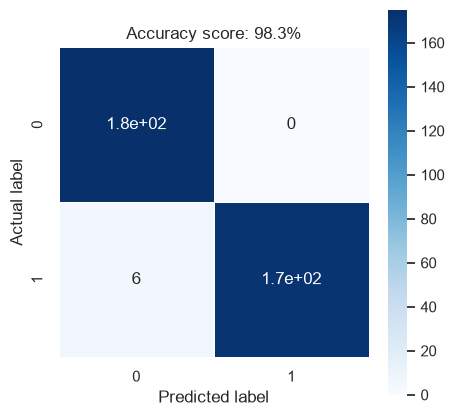

In [550]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,5))
sns.heatmap(data=cm_dt, linewidth=.5, square=True, annot=True, cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'Accuracy score: {round(accuracy_score(y_test,y_pred_dt)*100,2)}%')
plt.show()

In [551]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [552]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred_rf = rfc.predict(X_test)

print(f"Accuracy score: {round(accuracy_score(y_test,y_pred_rf)*100,2)}%\n")
print(f"F1 score: {f1_score(y_test,y_pred_rf)}")
print(f"Precision score: {precision_score(y_test,y_pred_rf)}")
print(f"Recall score: {recall_score(y_test,y_pred_rf)}")

Accuracy score: 98.87%

F1 score: 0.9886363636363636
Precision score: 1.0
Recall score: 0.9775280898876404


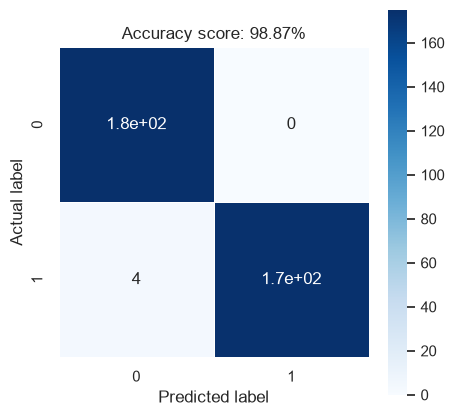

In [553]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,5))
sns.heatmap(data=cm_rf, linewidth=.5, square=True, annot=True, cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'Accuracy score: {round(accuracy_score(y_test,y_pred_rf)*100,2)}%')
plt.show()

In [554]:
#KNN

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [555]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred_knn = knn.predict(X_test)

print(f"Accuracy score: {round(accuracy_score(y_test,y_pred_knn)*100,2)}%\n")
print(f"F1 score: {f1_score(y_test,y_pred_knn)}")
print(f"Precision score: {precision_score(y_test,y_pred_knn)}")
print(f"Recall score: {recall_score(y_test,y_pred_knn)}")

Accuracy score: 94.62%

F1 score: 0.9436201780415431
Precision score: 1.0
Recall score: 0.8932584269662921


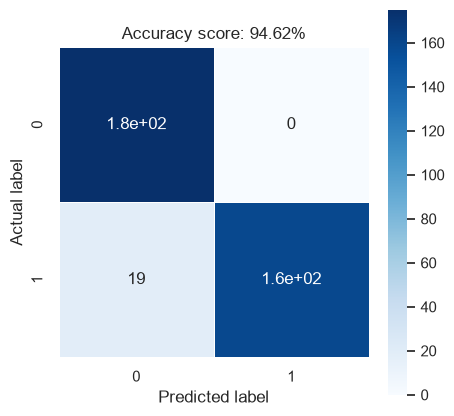

In [556]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,5))
sns.heatmap(data=cm_knn, linewidth=.5, square=True, annot=True, cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'Accuracy score: {round(accuracy_score(y_test,y_pred_knn)*100,2)}%')
plt.show()

In [557]:
#Adaboost

from sklearn.ensemble import AdaBoostClassifier
adb = AdaBoostClassifier(random_state=42)
adb.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [558]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred_adb = adb.predict(X_test)

print(f"Accuracy score: {round(accuracy_score(y_test,y_pred_adb)*100,2)}%\n")
print(f"F1 score: {f1_score(y_test,y_pred_adb)}")
print(f"Precision score: {precision_score(y_test,y_pred_adb)}")
print(f"Recall score: {recall_score(y_test,y_pred_adb)}")

Accuracy score: 97.73%

F1 score: 0.9774011299435028
Precision score: 0.9829545454545454
Recall score: 0.9719101123595506


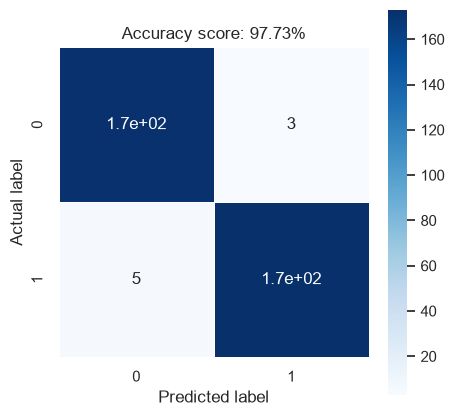

In [559]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_adb = confusion_matrix(y_test, y_pred_adb)

plt.figure(figsize=(5,5))
sns.heatmap(data=cm_adb, linewidth=.5, square=True, annot=True, cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'Accuracy score: {round(accuracy_score(y_test,y_pred_adb)*100,2)}%')
plt.show()

In [560]:
#Logistic Regression


from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [561]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

y_pred = lr.predict(X_test)

print(f"Accuracy score: {round(accuracy_score(y_test,y_pred)*100,2)}%\n")
print(f"F1 score: {f1_score(y_test,y_pred)}")
print(f"Precision score: {precision_score(y_test,y_pred)}")
print(f"Recall score: {recall_score(y_test,y_pred)}")

Accuracy score: 97.45%

F1 score: 0.9740634005763689
Precision score: 1.0
Recall score: 0.949438202247191


Text(0.5, 1.0, 'Accuracy score: 97.45%')

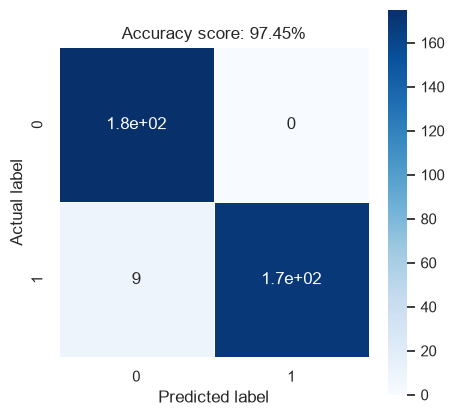

In [562]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(data=cm,linewidth=.5,square = True,annot = True,cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
all_sample_title = 'Accuracy score: {0}%'.format(round(accuracy_score(y_test,y_pred)*100,2))
plt.title(all_sample_title)

In [563]:
import pandas as pd

# Taking user inputs
distance = float(input("Enter distance (km): "))
prep_time = float(input("Enter preparation time (min): "))
experience = float(input("Enter courier experience (yrs): "))

weather = input("Enter weather (foggy/rainy/snowy/windy/clear): ").strip().lower()
traffic = input("Enter traffic (low/medium/high): ").strip().lower()
time_day = input("Enter time of day (morning/evening/night/afternoon): ").strip().lower()
vehicle = input("Enter vehicle (car/scooter/bike): ").strip().lower()

# Create dataframe for one input
new_input = pd.DataFrame({
    'Distance_km': [distance],
    'Preparation_Time_min': [prep_time],
    'Courier_Experience_yrs': [experience],

    'Weather_Foggy': [1 if weather == "foggy" else 0],
    'Weather_Rainy': [1 if weather == "rainy" else 0],
    'Weather_Snowy': [1 if weather == "snowy" else 0],
    'Weather_Windy': [1 if weather == "windy" else 0],

    'Traffic_Level_Low': [1 if traffic == "low" else 0],
    'Traffic_Level_Medium': [1 if traffic == "medium" else 0],

    'Time_of_Day_Evening': [1 if time_day == "evening" else 0],
    'Time_of_Day_Morning': [1 if time_day == "morning" else 0],
    'Time_of_Day_Night': [1 if time_day == "night" else 0],

    'Vehicle_Type_Car': [1 if vehicle == "car" else 0],
    'Vehicle_Type_Scooter': [1 if vehicle == "scooter" else 0]
})

# Prediction
prediction = rfc.predict(new_input)
confidence = rfc.predict_proba(new_input)

if prediction[0] == 1:
    print("Prediction:", "Late" if prediction[0] == 1 else "On-time")
else:
    print("Predicted Status: On-time")
print("Confidence:", round(confidence.max()*100,2), "%")

Predicted Status: On-time
Confidence: 81.0 %


In [564]:
import joblib
joblib.dump(rfc, "classifier.pkl")

['classifier.pkl']

In [565]:
#Till here the projects will the food be delivered on-time or not..
#CLASSIFICATION done........


In [566]:
#Regression



In [567]:
df_encoded['Delivery_status']

330    On-time
348    On-time
994    On-time
516    On-time
534    On-time
        ...   
995       Late
996       Late
997       Late
998       Late
999       Late
Name: Delivery_status, Length: 1764, dtype: object

In [568]:
df_encoded['Delivery_Time_min']

330    28
348    28
994    25
516    17
534    30
       ..
995    54
996    71
997    81
998    55
999    58
Name: Delivery_Time_min, Length: 1764, dtype: int64

In [569]:
y_reg = df2['Delivery_Time_min']

In [570]:
#Dropping Delivery_status bcz the its derived from delivery time..This might cause data leakage
X_reg = df_encoded.drop(['Delivery_Time_min', 'Delivery_status'], axis=1)
X_reg

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
330,3.12,14,5.0,False,True,False,False,True,False,True,False,False,False,True
348,2.83,14,6.0,False,False,False,True,False,True,False,False,False,False,True
994,4.37,6,7.0,False,False,False,False,False,True,True,False,False,False,True
516,2.33,6,1.0,False,False,False,False,True,False,False,True,False,True,False
534,3.40,11,6.0,False,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,13,3.0,False,False,False,False,False,False,True,False,False,True,False
996,16.28,8,9.0,False,True,False,False,True,False,False,True,False,False,True
997,15.62,26,2.0,False,False,True,False,False,False,True,False,False,False,True
998,14.17,8,0.0,False,False,False,False,True,False,False,False,False,False,False


In [571]:
X_reg = X_reg.astype(int)
X_reg

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
330,3,14,5,0,1,0,0,1,0,1,0,0,0,1
348,2,14,6,0,0,0,1,0,1,0,0,0,0,1
994,4,6,7,0,0,0,0,0,1,1,0,0,0,1
516,2,6,1,0,0,0,0,1,0,0,1,0,1,0
534,3,11,6,0,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8,13,3,0,0,0,0,0,0,1,0,0,1,0
996,16,8,9,0,1,0,0,1,0,0,1,0,0,1
997,15,26,2,0,0,1,0,0,0,1,0,0,0,1
998,14,8,0,0,0,0,0,1,0,0,0,0,0,0


In [572]:
from sklearn.model_selection import train_test_split

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split( X_reg, y_reg, test_size=0.2, random_state=42)

In [573]:
#Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [574]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_dt = dt_reg.predict(X_test_reg)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_dt))
print("MSE:", mean_squared_error(y_test_reg, y_pred_dt))
print("R2 Score:", r2_score(y_test_reg, y_pred_dt))

MAE: 6.113314447592068
MSE: 155.52974504249292
R2 Score: 0.7318763706461191


In [575]:
#Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [576]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_rf = rf_reg.predict(X_test_reg)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_rf))
print("MSE:", mean_squared_error(y_test_reg, y_pred_rf))
print("R2 Score:", r2_score(y_test_reg, y_pred_rf))

MAE: 4.3057261567516525
MSE: 69.64246891973559
R2 Score: 0.8799407051119212


In [577]:
#AdaBoost Regressor

from sklearn.ensemble import AdaBoostRegressor
adb_reg = AdaBoostRegressor(random_state=42)
adb_reg.fit(X_train_reg, y_train_reg)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.If ``None``, then the base estimator is:class:`~sklearn.tree.DecisionTreeRegressor` initialized with`max_depth=3`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each regressor at each boosting iteration. A higherlearning rate increases the contribution of each regressor. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"loss loss: {'linear', 'square', 'exponential'}, default='linear'The loss function to use when updating the weights after eachboosting iteration.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.In addition, it controls the bootstrap of the weights used to train the`estimator` at each boosting iteration.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [578]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_adb_reg = adb_reg.predict(X_test_reg)

print("AdaBoost Regressor")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_adb_reg))
print("MSE:", mean_squared_error(y_test_reg, y_pred_adb_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_adb_reg))

AdaBoost Regressor
MAE: 11.87481728033865
MSE: 185.97853243143103
R2 Score: 0.6793845506285638


In [579]:
#Linear Regression model


from sklearn.linear_model import LinearRegression

linR = LinearRegression()
linR.fit(X_train_reg, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [580]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_reg = linR.predict(X_test_reg)

print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("MSE:", mean_squared_error(y_test_reg, y_pred_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_reg))

MAE: 4.7635050788331395
MSE: 71.00025469224926
R2 Score: 0.8775999666948939


In [581]:
import pandas as pd

distance = float(input("Enter distance (km): "))
prep_time = float(input("Enter preparation time (min): "))
experience = float(input("Enter courier experience (yrs): "))

weather = input("Enter weather (Foggy/Rainy/Snowy/Windy/Clear): ").strip().lower()
traffic = input("Enter traffic (Low/Medium/High): ").strip().lower()
time_day = input("Enter time of day (Morning/Evening/Night): ").strip().lower()
vehicle = input("Enter vehicle (Car/Scooter/Bike): ").strip().lower()

new_data = pd.DataFrame({
    'Distance_km': [distance],
    'Preparation_Time_min': [prep_time],
    'Courier_Experience_yrs': [experience],

    'Weather_Foggy': [1 if weather == "foggy" else 0],
    'Weather_Rainy': [1 if weather == "rainy" else 0],
    'Weather_Snowy': [1 if weather == "snowy" else 0],
    'Weather_Windy': [1 if weather == "windy" else 0],

    'Traffic_Level_Low': [1 if traffic == "low" else 0],
    'Traffic_Level_Medium': [1 if traffic == "medium" else 0],

    'Time_of_Day_Evening': [1 if time_day == "evening" else 0],
    'Time_of_Day_Morning': [1 if time_day == "morning" else 0],
    'Time_of_Day_Night': [1 if time_day == "night" else 0],

    'Vehicle_Type_Car': [1 if vehicle == "car" else 0],
    'Vehicle_Type_Scooter': [1 if vehicle == "scooter" else 0]
})

predicted_time = rf_reg.predict(new_data)[0]

print("Predicted Delivery Time:", round(predicted_time, 2), "minutes")

if predicted_time <= 30:
    print("Delivery Status: On-time")
else:
    print("Delivery Status: Late")

Predicted Delivery Time: 62.99 minutes
Delivery Status: Late


In [582]:
import joblib

joblib.dump(rf_reg, "model.pkl")

['model.pkl']